In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [4]:
hour_data = pd.read_csv("../data/processed/hour_features.csv")

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")


In [5]:
def euclidean_dist(point_a, point_b):
    total=0
    for a, b in zip(point_a, point_b):
        total+=(a-b)**2
    return math.sqrt(total)

In [6]:
def calculate_distance(X_train, y_train, new_point):
    distances=[]
    for point, target in zip(X_train, y_train):
        distance=euclidean_dist(point, new_point)
        distances.append((distance, target))
    return distances

In [7]:
def get_neighbors(distances, k):
    distances.sort()
    return distances[:k]


In [8]:
def predict_one(neighbors):
    values=[]
    for distance, target in neighbors:
        values.append(target)
    return sum(values)/len(values)

In [9]:
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

13903
13903
3476
3476


In [10]:
#take row and make a list
new_point = X_test.iloc[0].tolist()
print(new_point)

[1.5736791319572767, 1.6399921604727272, -0.4003064729517819, -0.4560986385560561, -0.4552036205968723, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]


In [11]:
def predict(X_train, y_train, X_test, k):
    predictions=[]

    X_train_list=X_train.values.tolist()
    y_train_list=y_train.iloc[:, 0].tolist() 
    X_test_list=X_test.values.tolist()

    for test_point in X_test_list:
        distances=calculate_distance(X_train_list, y_train_list, test_point)
        neighbors=get_neighbors(distances, k)
        pred=predict_one(neighbors)
        predictions.append(pred)
    return predictions

y_pred = predict(X_train, y_train, X_test, k=12)



In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.2f}")

MAE: 75.66
RMSE: 107.13
R2: 0.76


In [13]:
y_test_values=[float(x) for x in np.array(y_test).ravel()]
y_pred_values=[float(x) for x in np.array(y_pred).ravel()]

def mean_absolute_error(actual, predicted):
  total_error = 0
  for real, pred in zip(actual, predicted):
    total_error += abs(real - pred)
  return total_error / len(actual)

mae=mean_absolute_error(y_test_values, y_pred_values)
print(f"MAE: {mae:.2f}")

MAE: 75.66


In [14]:
def calc_rsme(actual, predicted):
    total=0
    for real, pred in zip(actual, predicted):
        total+=(real-pred)**2
    mean_error=total/len(actual)
    return mean_error**0.5

rmse=calc_rsme(y_test_values, y_pred_values)
print(f"RSME: {rmse:.2f}")

RSME: 107.13


In [15]:
def calc_r2(actual, predicted):
    mean_actual=sum(actual)/len(actual)
    total_sum=0
    residual_sum=0
    for real in actual:
        total_sum+=(real-mean_actual)**2
    for real, pred in zip(actual, predicted):
        residual_sum+=(real-pred)**2
    return 1-residual_sum/total_sum

r2=calc_r2(y_test_values, y_pred_values)
print(f"R2: {r2:.2f}")

R2: 0.76


In [16]:
y_train_values=[float(x) for x in np.array(y_train).ravel()]
baseline=sum(y_train_values)/len(y_train_values)
print("Baseline", baseline)

Baseline 174.63914263108683


In [17]:
baseline_pred=[]
for value in y_train_values:
    baseline_pred.append(baseline)

In [18]:
baseline_mae=mean_absolute_error(y_train_values, baseline_pred)
baseline_rsme=calc_rsme(y_train_values, baseline_pred)
baseline_r2=calc_r2(y_train_values, baseline_pred)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rsme:.2f}")
print(f"Baseline R2: {baseline_r2:.2f}")

Baseline MAE: 131.08
Baseline RMSE: 166.95
Baseline R2: 0.00


In [19]:
results = {
    "K": [2, 5, 9, 12],
    "MAE": [75.47, 74.69, 75.21, 75.66],
    "RMSE": [111.45, 107.94, 107.08, 107.13],
    "R2": [0.74, 0.76, 0.76, 0.76]
}
results_df = pd.DataFrame(results)
results_df

,K,MAE,RMSE,R2
0,2,75.47,111.45,0.74
1,5,74.69,107.94,0.76
2,9,75.21,107.08,0.76
3,12,75.66,107.13,0.76


We can notice that after k=5, r2 doesn't change, so we can think that it is the best k.

In [20]:
best_k=5
best_pred=predict(X_train, y_train, X_test, best_k)

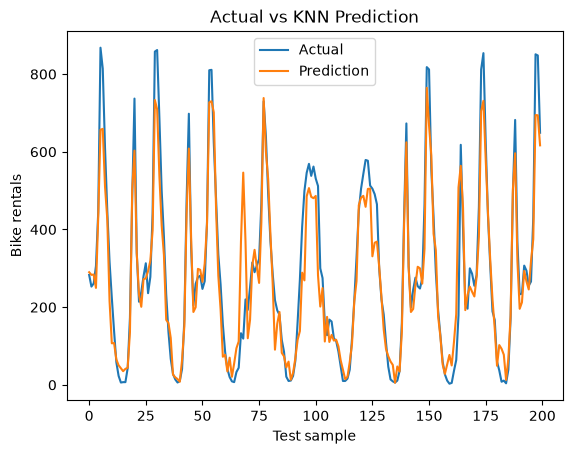

In [21]:
plt.plot(
    y_test_values[:200],
    label="Actual"
)

plt.plot(
    best_pred[:200],
    label="Prediction"
)

plt.xlabel("Test sample")
plt.ylabel("Bike rentals")
plt.title("Actual vs KNN Prediction")
plt.legend()
plt.show()

Graph shows how prediction of KNN repeats the actual cnt. The model generally reproduces the main changes in demand, but can smooth out sharp peaks and drops

In [22]:
errors=[]
for real, pred in zip(y_test_values, best_pred):
    error=abs(real-pred)
    errors.append(error)
print(errors[:10])

[7.0, 30.19999999999999, 23.0, 56.400000000000006, 13.0, 211.20000000000005, 155.0, 99.80000000000001, 21.600000000000023, 101.19999999999999]


In [23]:
max_error=max(errors)
print("Max error", max_error)

average_error=sum(errors)/len(errors)
print("Average error: ", average_error)

errors_results=[]
for real, pred in zip(y_test_values, best_pred):
    error=abs(real-pred)
    errors_results.append((error, real, pred))
errors_results.sort(reverse=True)
for result in errors_results[:10]:
    print(f"Error: {result[0]}, Real {result[1]}, Pred {result[2]}")

Max error 486.0
Average error:  74.69073647871116
Error: 486.0, Real 784.0, Pred 298.0
Error: 479.0, Real 779.0, Pred 300.0
Error: 447.4, Real 890.0, Pred 442.6
Error: 445.8, Real 839.0, Pred 393.2
Error: 445.8, Real 834.0, Pred 388.2
Error: 441.4, Real 724.0, Pred 282.6
Error: 427.4, Real 119.0, Pred 546.4
Error: 419.6, Real 66.0, Pred 485.6
Error: 412.8, Real 838.0, Pred 425.2
Error: 409.8, Real 884.0, Pred 474.2


In [24]:
actual_values = y_test.iloc[:, 0].tolist()

error_analysis = pd.DataFrame({
    "actual": actual_values,
    "prediction": best_pred
})

error_analysis["error"] = (error_analysis["actual"] - error_analysis["prediction"]).abs()
error_analysis["index"] = X_test.index
print(error_analysis.head())

error_analysis["hr"] = hour_data.loc[error_analysis["index"],"hr"].values
error_analysis["workingday"] = hour_data.loc[error_analysis["index"],"workingday"].values
error_analysis["season"] = hour_data.loc[error_analysis["index"],"season"].values
error_analysis["weathersit"] = hour_data.loc[error_analysis["index"], "weathersit"].values
error_analysis["time_of_day"] = hour_data.loc[error_analysis["index"],"time_of_day"].values

   actual  prediction  error  index
0     283       290.0    7.0      0
1     253       283.2   30.2      1
2     261       284.0   23.0      2
3     306       249.6   56.4      3
4     445       432.0   13.0      4


In [25]:
error_analysis.to_csv("../data/processed/knn_error_analysis.csv",index=False)

In [26]:
error_by_time=(error_analysis.groupby("time_of_day")["error"]).mean()
print(error_by_time)

time_of_day
Afternoon    104.828610
Evening       61.475441
Morning       77.462610
Night         58.943003
Name: error, dtype: float64


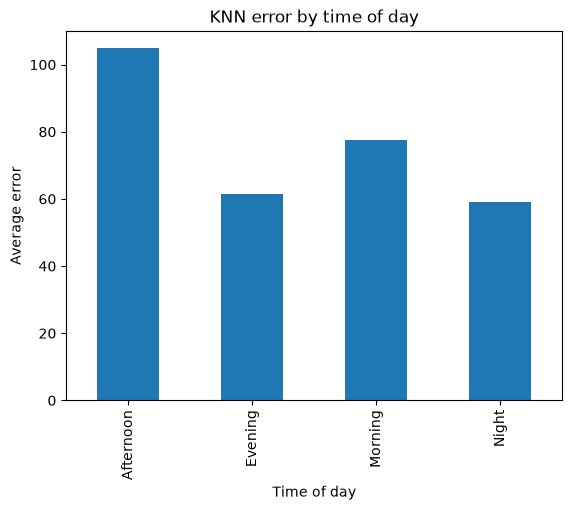

In [27]:
error_by_time.plot(kind="bar")
plt.xlabel("Time of day")
plt.ylabel("Average error")
plt.title("KNN error by time of day")
plt.show()

In [28]:
error_by_workingday=(error_analysis.groupby("workingday")["error"]).mean()
print(error_by_workingday)

workingday
0    71.458146
1    76.209302
Name: error, dtype: float64


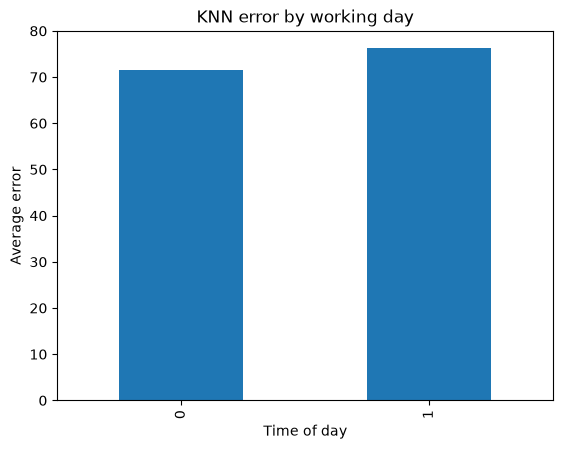

In [ ]:
error_by_workingday.plot(kind="bar")
plt.xlabel("Working day")
plt.ylabel("Average error")
plt.title("KNN error by working day")
plt.show()

In [30]:
error_by_season=(error_analysis.groupby("season")["error"]).mean()
print(error_by_season)

season
1    76.730382
2    72.482445
Name: error, dtype: float64


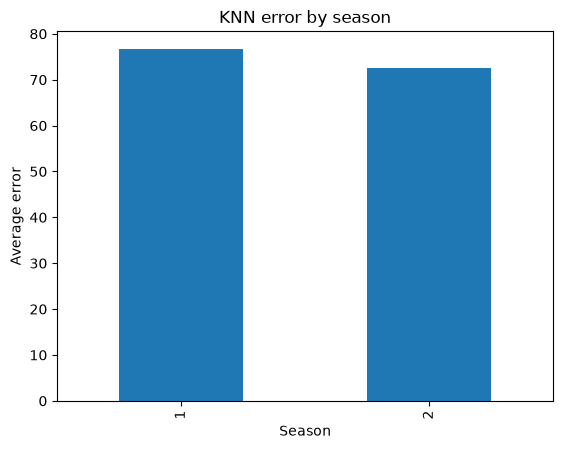

In [ ]:
#because of split we have only 2 seasons
error_by_season.plot(kind="bar")
plt.xlabel("Season")
plt.ylabel("Average error")
plt.title("KNN error by season")
plt.show()

In [33]:
error_by_weather=(error_analysis.groupby("weathersit")["error"]).mean()
print(error_by_weather)

weathersit
1    70.918313
2    81.947115
3    75.769054
4    21.000000
Name: error, dtype: float64


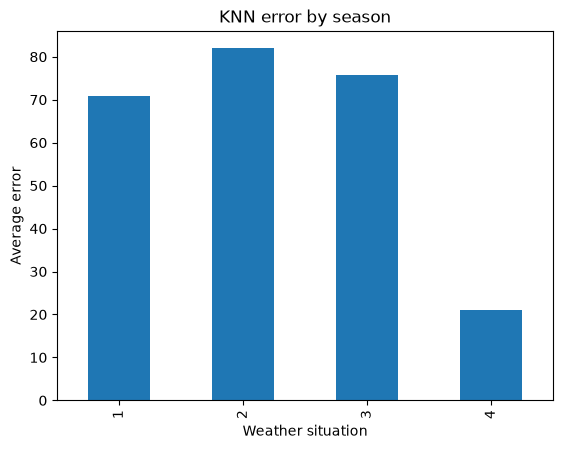

In [35]:
error_by_weather.plot(kind="bar")
plt.xlabel("Weather situation")
plt.ylabel("Average error")
plt.title("KNN error by season")
plt.show()